# Reinforcement Learning: A **value-based** TD Q Learning (simple example 1)
This example utilizes no deep learning or external libraries. It uses:
- Temporal Difference Q-learning (**value-based method**)
- Simple grid environment (4x4=16 states)
- The agent learns to reach the goal while avoiding obstacles

### Key concepts:
- **Agent**:	The learner navigating from (0,0)
- **Environment**:	The 4x4 grid = 16 states, with GOAL and OBSTACLES
- **Action**:	Move up, down, left, right
- **Observation**:	Current position on grid (x, y)
- **Reward**:	+10 for goal, -1 step penalty, -10 for obstacle

```
The update eq. for TD Q-Learning:
  Q(s, a) += α * (r + γ * max_a' Q(s', a') - Q(s, a))
α : The learning rate, which determines how much new information overrides old information 
γ : The discount factor, which determines the importance of future rewards
```

## Code explanation


```
Define Parameters:
    n_states : The total number of states in the environment (16 states).
    n_actions : The number of possible actions the agent can take (4 actions).
    goal_state : The state that the agent is trying to reach (state 15).

Q-Table Initialization:
    Q_table : A 2D array initialized to zeros: Each row corresponds to a state and each
    column corresponds to an action. This table will store the expected rewards (Q-values) for
    each state-action pair.

Learning Parameters:
    learning_rate : The rate at which the agent updates its Q-values (set to 0.8). 
    discount_factor : The factor that determines the importance of future rewards (set to 0.95). 
    exploration_prob : The probability of choosing a random action instead of the best-known action (set to 0.2).
    epochs : The number of training iterations (set to 1000).
```

## The main training loop runs for a specified number of epochs (1000):

```

Random Start: The agent starts in a random state within the range of available states (0 to 15).

While Loop: The agent continues to take actions until it reaches the goal state:
    
    1. Exploration vs. Exploitation:
    
        The agent decides whether to explore (choose a random action) or exploit (choose the best-known action based on the Q-table) using an ε-greedy policy:
            If a random number is less than exploration_prob, the agent selects a random action.
            Otherwise, it selects the action with the highest Q-value for the current state.

    2. State Transition: The agent moves to the next state. In this case, the next state is determined by a simple circular movement: it moves to the next state in a circular manner (if it reaches the last state, it wraps around to the first state).
    
    3. Reward Function: The agent receives a reward:
        It gets a reward of 1 if it reaches the goal state (state 15).
        It receives a reward of 0 for all other states.

    4. Q-Value Update Rule: The agent updates its Q-value for the current state and action using the Q-learning update formula:
    
        The Q-value is updated based on the received reward and the maximum Q-value of the next state, adjusted by the learning rate.

    5. Update Current State: The agent updates its current state to the next state
    
```

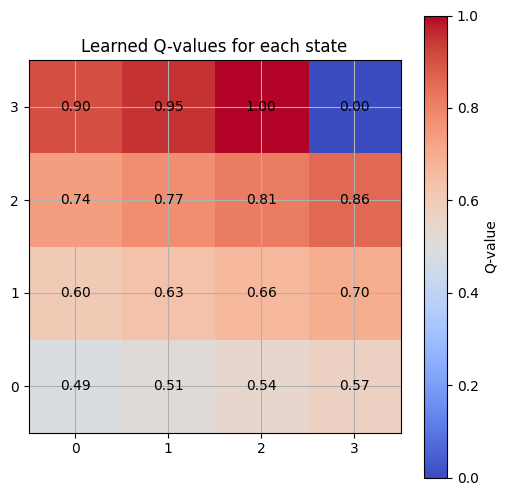

Learned Q-table:
[[0.49 0.49 0.47 0.39]
 [0.51 0.51 0.51 0.51]
 [0.54 0.54 0.54 0.54]
 [0.57 0.57 0.57 0.57]
 [0.6  0.6  0.6  0.6 ]
 [0.63 0.63 0.63 0.63]
 [0.66 0.66 0.66 0.66]
 [0.7  0.7  0.7  0.7 ]
 [0.74 0.74 0.74 0.74]
 [0.77 0.77 0.77 0.77]
 [0.81 0.81 0.81 0.81]
 [0.86 0.86 0.86 0.86]
 [0.9  0.9  0.9  0.9 ]
 [0.95 0.95 0.95 0.95]
 [1.   1.   1.   1.  ]
 [0.   0.   0.   0.  ]]


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
np.random.seed(42)

# Parameters
n_states = 16  
n_actions = 4 
goal_state = 15 

Q_table = np.zeros((n_states, n_actions))

learning_rate = 0.8
discount_factor = 0.95
exploration_prob = 0.2
epochs = 1000

# Q-learning process
for epoch in range(epochs):
    current_state = np.random.randint(0, n_states) 

    while current_state != goal_state:
        
        # Exploration vs. Exploitation (ϵ-greedy policy)
        if np.random.rand() < exploration_prob:
            action = np.random.randint(0, n_actions)  
        else:
            action = np.argmax(Q_table[current_state]) 

        # Transition to the next state (circular movement for simplicity)
        # Agent ALWAYS moves to the next state in a circular manner (0 → 1 → 2 → ... → 15 → 0).
        next_state = (current_state + 1) % n_states 

        # Reward function (1 if goal_state reached, 0 otherwise)
        reward = 1 if next_state == goal_state else 0

        # Q-value update rule (TD update)
        Q_table[current_state, action] += learning_rate * \
            (reward + discount_factor * np.max(Q_table[next_state]) - Q_table[current_state, action])

        current_state = next_state  # Update current state

# Visualization of the Q-table in a grid format 
q_values_grid = np.max(Q_table, axis=1).reshape((4, 4)) 


# Plot the grid of Q-values
plt.figure(figsize=(6, 6))
plt.imshow(q_values_grid, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Q-value')
plt.title('Learned Q-values for each state')
plt.xticks(np.arange(4), ['0', '1', '2', '3'])
plt.yticks(np.arange(4), ['0', '1', '2', '3'])
plt.gca().invert_yaxis()  # To match grid layout
plt.grid(True)

# Annotating the Q-values on the grid
for i in range(4):
    for j in range(4):
        plt.text(j, i, f'{q_values_grid[i, j]:.2f}', ha='center', va='center', color='black')

plt.show()

# Print learned Q-table
print("Learned Q-table:")
print(Q_table)


## observation
- In Q table, each row represents a state and values in the row represents an probability for an action. **For e.g. row_idx 2 and col_idx 1 has value 0.54 which indicates the probability that action 2 would be taken when state is 3**
- In above setup, the next state is always (current_state + 1) % n_states, no matter which action is taken. This means that all actions give the same result, so the agent cannot learn to prefer any one action over another. That's why **Q-values for all actions in a given state end up the same**.

## Improvement of above

Key Improvements:
- Agent now moves according to the action taken (up, down, left, right).
- Boundaries are respected — the agent can’t move off the grid.
- Rewards encourage the shortest path to the goal.
- Each row in the Q-table now reflects actual decisions, so Q-values will vary meaningfully.

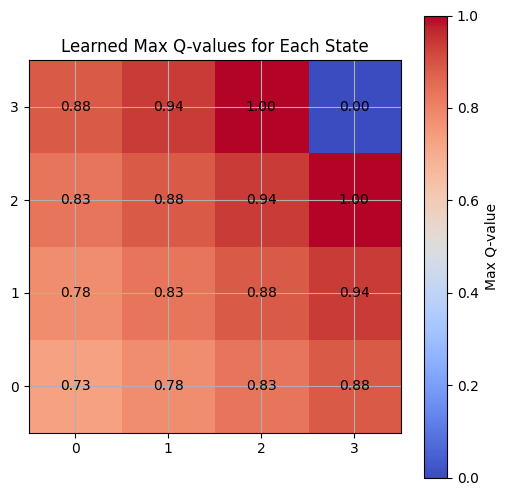

Learned Q-table:
[[ 0.68  0.73  0.68  0.73]
 [ 0.73  0.78  0.68  0.77]
 [ 0.77  0.83 -0.02  0.79]
 [ 0.83  0.88  0.77  0.79]
 [ 0.68  0.78  0.73  0.78]
 [ 0.73  0.83  0.73  0.83]
 [ 0.78  0.88  0.78  0.88]
 [ 0.83  0.94  0.83  0.88]
 [ 0.73  0.83  0.78  0.83]
 [ 0.78  0.88  0.78  0.88]
 [ 0.83  0.94  0.83  0.94]
 [ 0.88  1.    0.88  0.94]
 [ 0.77  0.83  0.82  0.88]
 [ 0.83  0.88  0.83  0.94]
 [ 0.88  0.94  0.88  1.  ]
 [ 0.    0.    0.    0.  ]]


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
np.random.seed(42)

# Grid environment: 4x4
grid_size = 4
n_states = grid_size * grid_size
n_actions = 4  # Up, Down, Left, Right
goal_state = 15

Q_table = np.zeros((n_states, n_actions))

# Hyperparameters
learning_rate = 0.8
discount_factor = 0.95
exploration_prob = 0.2
epochs = 1000

# Action mapping
actions = ['up', 'down', 'left', 'right']
action_deltas = {
    0: (-1, 0),  # up
    1: (1, 0),   # down
    2: (0, -1),  # left
    3: (0, 1)    # right
}

def state_to_coords(state):
    return divmod(state, grid_size)

def coords_to_state(x, y):
    return x * grid_size + y

def get_next_state(state, action):
    x, y = state_to_coords(state)
    dx, dy = action_deltas[action]
    nx, ny = x + dx, y + dy

    # Stay in bounds
    if 0 <= nx < grid_size and 0 <= ny < grid_size:
        return coords_to_state(nx, ny)
    return state  # Invalid move, stay in current state

# Q-learning training
for epoch in range(epochs):
    current_state = np.random.randint(0, n_states)

    while current_state != goal_state:
        
        # Exploration vs. Exploitation (ϵ-greedy policy)
        if np.random.rand() < exploration_prob:
            action = np.random.randint(0, n_actions)
        else:
            action = np.argmax(Q_table[current_state])

        next_state = get_next_state(current_state, action)
        reward = 1 if next_state == goal_state else -0.01  # small penalty to encourage shortest path

        # Q-learning update rule
        Q_table[current_state, action] += learning_rate * (
            reward + discount_factor * np.max(Q_table[next_state]) - Q_table[current_state, action]
        )

        current_state = next_state


# Optional: Print final Q-table
print("Learned Q-table:")
np.set_printoptions(precision=2, suppress=True)
print(Q_table)

#############PART2: FOLLOWING IS FOR VISUALIZATIO##################

# Visualizing Q-values (max over actions) as grid
q_values_grid = np.max(Q_table, axis=1).reshape((grid_size, grid_size))

plt.figure(figsize=(6, 6))
plt.imshow(q_values_grid, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Max Q-value')
plt.title('Learned Max Q-values for Each State')
plt.xticks(np.arange(grid_size), [str(i) for i in range(grid_size)])
plt.yticks(np.arange(grid_size), [str(i) for i in range(grid_size)])
plt.gca().invert_yaxis()

# Annotate the values
for i in range(grid_size):
    for j in range(grid_size):
        val = q_values_grid[i, j]
        plt.text(j, i, f'{val:.2f}', ha='center', va='center', color='black')

plt.grid(True)
plt.show()



